# 프로젝트 : mini BERT

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0. 환경 준비
---
사용할 라이브러리 버전을 둘러봅시다.

In [3]:
!mkdir -p /content/data /content/models
!wget https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip
!mv kowiki.txt.zip /content/data
%cd /content/data
!unzip -o kowiki.txt.zip
%cd /content

--2026-07-16 07:05:19--  https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip
Resolving d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)... 3.165.160.58, 3.165.160.93, 3.165.160.100, ...
Connecting to d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)|3.165.160.58|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 243123354 (232M) [application/zip]
Saving to: ‘kowiki.txt.zip’

kowiki.txt.zip      100%[===================>] 231.86M   297MB/s    in 0.8s    

2026-07-16 07:05:20 (297 MB/s) - ‘kowiki.txt.zip’ saved [243123354/243123354]

/content/data
Archive:  kowiki.txt.zip
  inflating: kowiki.txt              
/content


In [4]:
!pip install sentencepiece tqdm torchinfo

In [5]:
from __future__ import absolute_import, division, print_function, unicode_literals

import os, re, math, json, random, collections, copy
from datetime import datetime

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sentencepiece as spm
from tqdm import tqdm

print(torch.__version__)
print(np.__version__)
print(pd.__version__)

2.11.0+cu128
2.0.2
2.2.2


## 1. Tokenizer 준비 (vocab_size=8000)

In [6]:
corpus_file = '/content/data/kowiki.txt'
prefix = '/content/models/ko_8000'
vocab_size = 8000

spm.SentencePieceTrainer.train(
    f"--input={corpus_file} --model_prefix={prefix} --vocab_size={vocab_size + 7} "
    f"--model_type=bpe --max_sentence_length=999999 "
    f"--pad_id=0 --pad_piece=[PAD] --unk_id=1 --unk_piece=[UNK] "
    f"--bos_id=2 --bos_piece=[BOS] --eos_id=3 --eos_piece=[EOS] "
    f"--user_defined_symbols=[SEP],[CLS],[MASK]"
)

In [7]:
data_dir = '/content/data'
model_dir = '/content/models'

vocab = spm.SentencePieceProcessor()
vocab.load(f"{model_dir}/ko_8000.model")

# 특수 토큰 7개를 제외한 vocab list (랜덤 토큰 치환용)
vocab_list = []
for id in range(7, len(vocab)):
    if not vocab.is_unknown(id):
        vocab_list.append(vocab.id_to_piece(id))

print(len(vocab), len(vocab_list))

8007 8000


In [8]:
# 동작 확인
string_a = "추적추적 비가 내리는 날이었어 그날은 왠지 손님이 많아"
string_b = "손바닥 위엔 기쁨의 눈물이 흘러 컬컬한 목에 모주 한잔을 적셔"
tokens_org = ["[CLS]"] + vocab.encode_as_pieces(string_a) + ["[SEP]"] + vocab.encode_as_pieces(string_b) + ["[SEP]"]
print(tokens_org)

['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '[SEP]']


## 2. 데이터 전처리 (1) MASK 생성
띄어쓰기(단어) 단위로 후보를 묶어서 마스킹하는 방식을 그대로 사용합니다.

In [9]:
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    마스크 생성
    :param tokens: tokens (리스트, in-place로 아님. 내부에서 복사본 사용)
    :param mask_cnt: mask 개수 (전체 tokens의 15%)
    :param vocab_list: vocab list (random token 용)
    :return tokens: mask된 tokens
    :return mask_idx: mask된 token의 index
    :return mask_label: mask된 token의 원래 값
    """
    # 단어(띄어쓰기) 단위로 index 묶기
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue
        if 0 < len(cand_idx) and not token.startswith(u"\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])
    random.shuffle(cand_idx)

    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue
        dice = random.random()
        for index in index_set:
            masked_token = None
            if dice < 0.8:  # 80%: [MASK]
                masked_token = "[MASK]"
            elif dice < 0.9:  # 10%: 랜덤 토큰
                masked_token = random.choice(vocab_list)
            else:  # 10%: 원본 유지
                masked_token = tokens[index]
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label

In [10]:
# 확인
tokens = copy.deepcopy(tokens_org)
mask_cnt = max(1, int((len(tokens) - 3) * 0.15))
tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list)
print("tokens_org:", tokens_org)
print("tokens    :", tokens)
print("mask_idx  :", mask_idx)
print("mask_label:", mask_label)

tokens_org: ['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '[SEP]']
tokens    : ['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '[SEP]', '[MASK]', '[MASK]', '[MASK]', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '[MASK]', '[MASK]', '[MASK]', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '[SEP]']
mask_idx  : [24, 25, 26, 36, 37, 38]
mask_label: ['▁손', '바', '닥', '▁컬', '컬', '한']


## 3. 데이터 전처리 (2) NSP pair 생성

In [11]:
def load_documents(corpus_file):
    """ 문서 단위로 원문(문자열) 리스트를 로딩. 토큰화는 하지 않음 (메모리 절약) """
    documents = []
    current_doc = []
    with open(corpus_file, "r") as f:
        for line in f:
            line = line.strip()
            if line == "":
                if current_doc:
                    documents.append(current_doc)
                    current_doc = []
            else:
                current_doc.append(line)
    if current_doc:
        documents.append(current_doc)
    return documents

In [12]:
def trim_tokens(tokens_a, tokens_b, max_seq):
    """ tokens_a, tokens_b 길이 합을 max_seq 이하로 자름 """
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break
        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()


def create_pretrain_instances(vocab, doc_index, all_documents, n_seq, mask_prob, vocab_list):
    """
    all_documents[doc_index] 문서로부터 NSP + MLM instance 생성
    NotNext(FALSE) 케이스는 반드시 '다른' 문서에서 문장을 가져옴
    """
    max_seq = n_seq - 3
    doc = [vocab.encode_as_pieces(line) for line in all_documents[doc_index]]

    instances = []
    current_chunk = []
    current_length = 0

    for i in range(len(doc)):
        current_chunk.append(doc[i])
        current_length += len(doc[i])

        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = 1
            if 1 < len(current_chunk):
                a_end = random.randrange(1, len(current_chunk))
            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])

            tokens_b = []
            if len(current_chunk) == 1 or random.random() < 0.5:
                # NotNext: 반드시 '다른' 문서에서 가져옴
                is_next = 0
                tokens_b_len = max_seq - len(tokens_a)

                random_doc_index = doc_index
                while random_doc_index == doc_index and len(all_documents) > 1:
                    random_doc_index = random.randrange(0, len(all_documents))

                random_doc_lines = all_documents[random_doc_index]
                random_start = random.randrange(0, len(random_doc_lines))
                for j in range(random_start, len(random_doc_lines)):
                    pieces = vocab.encode_as_pieces(random_doc_lines[j])
                    if 0 < len(pieces):
                        tokens_b.extend(pieces)
                        if tokens_b_len <= len(tokens_b):
                            break
            else:
                is_next = 1
                for j in range(a_end, len(current_chunk)):
                    tokens_b.extend(current_chunk[j])

            trim_tokens(tokens_a, tokens_b, max_seq)

            if len(tokens_a) == 0 or len(tokens_b) == 0:
                current_chunk = []
                current_length = 0
                continue

            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

            mask_cnt = max(1, int((len(tokens) - 3) * mask_prob))
            tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list)

            instances.append({
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label,
            })

            current_chunk = []
            current_length = 0

    return instances

In [14]:
# 동작 확인
string = """추적추적 비가 내리는 날이었어
그날은 왠지 손님이 많아
첫 번에 삼십 전 둘째 번 오십 전
오랜만에 받아보는 십 전짜리 백통화 서푼에"""

string2 = """전혀 다른 내용의 두 번째 문서입니다
오늘 날씨가 참 좋네요
저녁에 산책을 다녀왔습니다"""

# all_documents: 문서 단위 리스트의 리스트 (각 문서는 줄 단위 문자열 리스트)
all_documents_test = [
    string.split("\n"),
    string2.split("\n"),
]

instances = create_pretrain_instances(vocab, 0, all_documents_test, 64, 0.15, vocab_list)
for instance in instances:
    print(instance)

{'tokens': ['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '[MASK]', '[MASK]', '▁번', '▁오', '십', '▁전', '[SEP]', '[MASK]', '▁다른', '▁내용', '의', '▁두', '▁번째', '▁문서', '입', '니다', '▁오늘', '▁날', '씨', '가', '▁참', '▁항공', '營', 'か', '▁저', '녁', '에', '▁산', '책', '을', '▁다', '녀', '왔', '습니다', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next': 0, 'mask_idx': [29, 30, 32, 33, 36, 37, 50, 51, 52], 'mask_label': ['▁둘', '째', '▁오', '십', '▁전혀', '▁다른', '▁좋', '네', '요']}


## 4. 데이터 전처리 (3) 데이터셋 완성 (json + np.memmap)

In [15]:
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    print("문서 로딩 중 (원문 텍스트만, 토큰화는 아직 안 함)...")
    all_documents = load_documents(in_file)
    print(f"전체 문서 수: {len(all_documents)}")

    with open(out_file, "w") as out_f:
        for doc_index in tqdm(range(len(all_documents))):
            instances = create_pretrain_instances(vocab, doc_index, all_documents, n_seq, mask_prob, vocab_list)
            for instance in instances:
                out_f.write(json.dumps(instance, ensure_ascii=False))
                out_f.write("\n")

In [17]:
n_seq = 128
pretrain_json_path = '/content/data/mini_bert_pretrain_v2.json'

make_pretrain_data(vocab, corpus_file, pretrain_json_path, n_seq)

문서 로딩 중 (원문 텍스트만, 토큰화는 아직 안 함)...
전체 문서 수: 502261


100%|██████████| 502261/502261 [06:32<00:00, 1280.72it/s]


나무위키 코퍼스에는 특수기호/숫자/기호로만 이루어진 줄이 꽤 있어서, encode_as_pieces() 결과가 빈 리스트로 나오는 경우가 실제로 존재  
-> 1) 문서를 만들 때 빈 인코딩 줄을 아예 제외  
   2) create_pretrain_instances에서 만약을 대비한 방어 코드 추가 (assert 대신 skip)

In [18]:
# 생성된 라인 수 확인
total = 0
with open(pretrain_json_path, "r") as f:
    for line in f:
        total += 1
print("전체 instance 수:", total)

전체 instance 수: 918120


In [19]:
def load_pre_train_data(vocab, filename, n_seq, count=None):
    """
    memmap 기반 pretrain 데이터 로더
    :return enc_tokens, segments, labels_nsp, labels_mlm
    """
    total = 0
    with open(filename, "r") as f:
        for line in f:
            total += 1
            if count is not None and count <= total:
                break
    if count is not None:
        total = min(total, count)

    enc_tokens = np.memmap(filename='enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    segments = np.memmap(filename='segments.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename='labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename='labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))

    with open(filename, "r") as f:
        for i, line in enumerate(tqdm(f, total=total)):
            if i >= total:
                break
            data = json.loads(line)

            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [0] * (n_seq - len(enc_token))

            segment = list(data["segment"]) + [0] * (n_seq - len(data["segment"]))

            label_nsp = data["is_next"]

            label_mlm = [0] * n_seq
            for idx, label in zip(data["mask_idx"], data["mask_label"]):
                label_mlm[idx] = vocab.piece_to_id(label)

            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    return (enc_tokens, segments), (labels_nsp, labels_mlm)

In [20]:
# 1M 파라미터 모델이므로 전체 데이터를 다 안 써도 충분합니다. 필요시 count 조정
pre_train_inputs, pre_train_labels = load_pre_train_data(vocab, pretrain_json_path, n_seq, count=200000)

print(pre_train_inputs[0].shape, pre_train_inputs[1].shape)
print(pre_train_labels[0].shape, pre_train_labels[1].shape)

100%|██████████| 200000/200000 [00:30<00:00, 6524.86it/s]

(200000, 128) (200000, 128)
(200000,) (200000, 128)


## 5. BERT 모델 구현
유틸리티

In [21]:
def get_pad_mask(tokens, i_pad=0):
    """ pad mask: (bs, 1, n_seq) 형태, pad=1 """
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1)
    return mask


def get_ahead_mask(tokens, i_pad=0):
    """ BERT는 encoder-only라 실제로는 사용 안 하지만 범용 유틸로 구현 """
    n_seq = tokens.size(1)
    ahead_mask = torch.triu(torch.ones(n_seq, n_seq, device=tokens.device), diagonal=1)
    ahead_mask = ahead_mask.unsqueeze(0).expand(tokens.size(0), -1, -1)
    pad_mask = get_pad_mask(tokens, i_pad).expand(-1, n_seq, -1)
    return torch.clamp(ahead_mask + pad_mask, max=1)


def gelu(x):
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))


def kernel_initializer(stddev=0.02):
    return torch.nn.init.trunc_normal_


def bias_initializer():
    return torch.zeros_


class Config(dict):
    """ json을 config 형태로 사용하기 위한 Class """
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        with open(file, 'r') as f:
            config = json.loads(f.read())
            return Config(config)

Embedding

In [22]:
class SharedEmbedding(nn.Module):
    """ 입력 token embedding과 출력(MLM) projection을 공유하는 임베딩 (파라미터 절약) """
    def __init__(self, config):
        super().__init__()
        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)

    def forward(self, inputs, mode="embedding"):
        if mode == "embedding":
            return F.embedding(inputs, self.shared_weights)
        elif mode == "projection":
            # inputs: (bs, n_seq, d_model) -> (bs, n_seq, n_vocab)
            return torch.matmul(inputs, self.shared_weights.transpose(0, 1))


class PositionEmbedding(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        position_ids = torch.arange(inputs.size(1), device=inputs.device).unsqueeze(0).expand_as(inputs)
        return self.embedding(position_ids)

Attention / FFN / Encoder Layer

In [23]:
class ScaleDotProductAttention(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        d_head = K.size(-1)
        scores = torch.matmul(Q, K.transpose(-1, -2)) / math.sqrt(d_head)
        scores = scores.masked_fill(attn_mask.bool(), -1e9)
        attn_prob = F.softmax(scores, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out


class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        self.W_Q = nn.Linear(self.d_model, self.n_head * self.d_head)
        self.W_K = nn.Linear(self.d_model, self.n_head * self.d_head)
        self.W_V = nn.Linear(self.d_model, self.n_head * self.d_head)
        self.scaled_dot_attn = ScaleDotProductAttention()
        self.linear = nn.Linear(self.n_head * self.d_head, self.d_model)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, Q, K, V, attn_mask):
        batch_size = Q.size(0)

        q_s = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        k_s = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        v_s = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)

        attn_mask = attn_mask.unsqueeze(1).expand(-1, self.n_head, -1, -1)

        context = self.scaled_dot_attn(q_s, k_s, v_s, attn_mask)
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.n_head * self.d_head)

        output = self.dropout(self.linear(context))
        return output


class PositionWiseFeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, inputs):
        output = gelu(self.W_1(inputs))
        output = self.dropout(self.W_2(output))
        return output


class EncoderLayer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

    def forward(self, inputs, attn_mask):
        attn_out = self.self_attention(inputs, inputs, inputs, attn_mask)
        norm1_out = self.norm1(inputs + attn_out)
        ffn_out = self.ffn(norm1_out)
        norm2_out = self.norm2(norm1_out + ffn_out)
        return norm2_out

BERT / PreTrainModel

In [24]:
class BERT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.dropout = nn.Dropout(config.dropout)

        self.layers = nn.ModuleList([EncoderLayer(config) for _ in range(config.n_layer)])

    def forward(self, enc_tokens, segments):
        attn_mask = get_pad_mask(enc_tokens, self.i_pad)
        n_seq = enc_tokens.size(1)
        attn_mask = attn_mask.expand(-1, n_seq, -1)  # (bs, n_seq, n_seq)

        hidden = self.embedding(enc_tokens, mode="embedding") + self.position(enc_tokens) + self.segment(segments)
        hidden = self.dropout(self.norm(hidden))

        for layer in self.layers:
            hidden = layer(hidden, attn_mask)

        logits_cls = hidden[:, 0]  # [CLS] 위치 -> NSP용
        logits_lm = self.embedding(hidden, mode="projection")  # MLM용
        return logits_cls, logits_lm


class PooledOutput(nn.Module):
    def __init__(self, config, n_output):
        super().__init__()
        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)

    def forward(self, inputs):
        output = torch.tanh(self.dense1(inputs))
        output = self.dense2(output)
        return output


class PreTrainModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()

        logits_cls, logits_lm = self.bert(enc_tokens, segments)
        logits_nsp = self.pooled_output(logits_cls)  # raw logits, softmax는 CrossEntropyLoss가 처리
        return logits_nsp, logits_lm


def build_model_pre_train(config):
    return PreTrainModel(config)

1M 파라미터 config 만들기
vocab_size=8000이 이미 임베딩 파라미터를 많이 잡아먹기 때문에  (vocab_size × d_model), d_model을 작게 유지해야 전체 1M 근처로 맞출 수 있습니다.

In [25]:
config = Config({
    "d_model": 64,
    "n_head": 4,
    "d_head": 16,
    "dropout": 0.1,
    "d_ff": 512,
    "layernorm_epsilon": 1e-6,
    "n_layer": 4,
    "n_seq": n_seq,
    "n_vocab": len(vocab),
    "i_pad": 0,
})

test_model = build_model_pre_train(config)
total_params = sum(p.numel() for p in test_model.parameters())
print(f"전체 파라미터 수: {total_params:,}")

전체 파라미터 수: 857,216


## 6. Pretrain 진행
loss / accuracy

In [26]:
def lm_loss(y_true, y_pred):
    """ MLM loss: pad(0) 위치는 loss에서 제외, mlm을 더 잘 학습하도록 20배 증가 """
    loss = F.cross_entropy(y_pred.view(-1, y_pred.size(-1)), y_true.view(-1), reduction='none')
    mask = (y_true != 0).float().view(-1)
    loss = (loss * mask).sum() / mask.sum().clamp(min=1)
    return loss * 20


def lm_acc(y_true, y_pred):
    y_pred_class = torch.argmax(y_pred, dim=-1)
    matches = (y_true == y_pred_class).float()
    mask = (y_true != 0).float()
    matches = matches * mask
    return matches.sum() / mask.sum().clamp(min=1)


def nsp_loss_fn(y_true, y_pred):
    return F.cross_entropy(y_pred, y_true)


def nsp_acc(y_true, y_pred):
    y_pred_class = torch.argmax(y_pred, dim=-1)
    return (y_true == y_pred_class).float().mean()

Learning Rate 스케줄 (Warmup + Cosine)

In [27]:
class CosineSchedule:
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0

    def step(self):
        self.step_num += 1
        if self.step_num < self.warmup_steps:
            lr = self.max_lr * (self.step_num / self.warmup_steps)
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            lr = self.max_lr * 0.5 * (1 + math.cos(math.pi * min(progress, 1.0)))
        if self.optimizer is not None:
            for pg in self.optimizer.param_groups:
                pg['lr'] = lr
        return lr

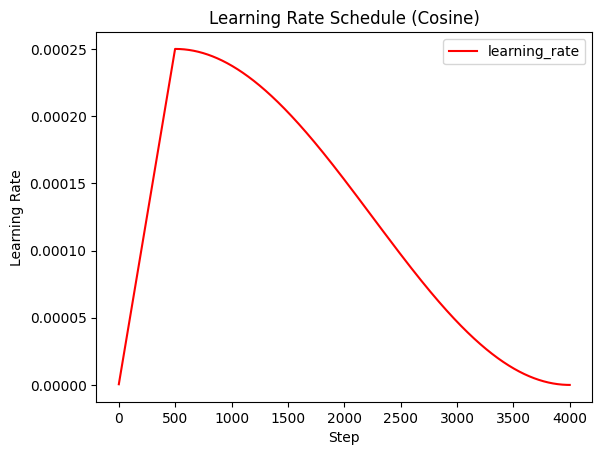

In [28]:
# 스케줄 모양 확인
test_schedule = CosineSchedule(train_steps=4000, warmup_steps=500)
lrs = [test_schedule.step() for _ in range(4000)]
plt.plot(lrs, 'r-', label='learning_rate')
plt.xlabel('Step'); plt.ylabel('Learning Rate'); plt.legend()
plt.title('Learning Rate Schedule (Cosine)')
plt.show()

모델 최종 빌드 + summary

In [29]:
from torchinfo import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pre_train_model = build_model_pre_train(config).to(device)

enc_tokens_example = torch.randint(0, config.n_vocab, (10, config.n_seq), dtype=torch.long).to(device)
segments_example = torch.randint(0, 2, (10, config.n_seq), dtype=torch.long).to(device)

summary(pre_train_model, input_data=[enc_tokens_example, segments_example])

Layer (type:depth-idx)                                       Output Shape              Param #
PreTrainModel                                                [10, 2]                   --
├─BERT: 1-1                                                  [10, 64]                  --
│    └─SharedEmbedding: 2-1                                  [10, 128, 64]             512,448
│    └─PositionEmbedding: 2-2                                [10, 128, 64]             --
│    │    └─Embedding: 3-1                                   [10, 128, 64]             8,192
│    └─Embedding: 2-3                                        [10, 128, 64]             128
│    └─LayerNorm: 2-4                                        [10, 128, 64]             128
│    └─Dropout: 2-5                                          [10, 128, 64]             --
│    └─ModuleList: 2-6                                       --                        --
│    │    └─EncoderLayer: 3-2                                [10, 128, 64]           

10 Epoch 학습
작은 모델(약 1M)이라 배치 사이즈를 128~256까지도 키울 수 있습니다. GPU 메모리 상황을 보며 조정하세요.

In [30]:
pre_train_inputs_t = [torch.tensor(np.array(x)) for x in pre_train_inputs]
pre_train_labels_t = [torch.tensor(np.array(x)) for x in pre_train_labels]

train_dataset = TensorDataset(pre_train_inputs_t[0], pre_train_inputs_t[1],
                               pre_train_labels_t[0], pre_train_labels_t[1])

batch_size = 128
epochs = 10

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

train_steps = math.ceil(len(train_dataset) / batch_size) * epochs
print("train_steps:", train_steps)

optimizer = optim.Adam(pre_train_model.parameters(), lr=1e-4)
lr_scheduler = CosineSchedule(optimizer=optimizer, train_steps=train_steps,
                               warmup_steps=max(100, train_steps // 10), max_lr=2.5e-4)

history = {"nsp_loss": [], "mlm_loss": [], "nsp_acc": [], "mlm_acc": []}

pre_train_model.train()
for epoch in range(1, epochs + 1):
    sums = {"nsp_loss": 0.0, "mlm_loss": 0.0, "nsp_acc": 0.0, "mlm_acc": 0.0}
    n_batches = 0

    for enc_tokens_b, segments_b, labels_nsp_b, labels_mlm_b in tqdm(train_dataloader, desc=f"Epoch {epoch}"):
        enc_tokens_b = enc_tokens_b.to(device).long()
        segments_b = segments_b.to(device).long()
        labels_nsp_b = labels_nsp_b.to(device).long()
        labels_mlm_b = labels_mlm_b.to(device).long()

        optimizer.zero_grad()
        logits_nsp, logits_mlm = pre_train_model(enc_tokens_b, segments_b)

        loss_nsp = nsp_loss_fn(labels_nsp_b, logits_nsp)
        loss_mlm = lm_loss(labels_mlm_b, logits_mlm)
        loss = loss_nsp + loss_mlm

        loss.backward()
        torch.nn.utils.clip_grad_norm_(pre_train_model.parameters(), max_norm=1.0)
        optimizer.step()
        lr_scheduler.step()

        sums["nsp_loss"] += loss_nsp.item()
        sums["mlm_loss"] += loss_mlm.item()
        sums["nsp_acc"] += nsp_acc(labels_nsp_b, logits_nsp).item()
        sums["mlm_acc"] += lm_acc(labels_mlm_b, logits_mlm).item()
        n_batches += 1

    for k in history:
        history[k].append(sums[k] / n_batches)

    print(f"[Epoch {epoch}/{epochs}] "
          f"nsp_loss={history['nsp_loss'][-1]:.4f} mlm_loss={history['mlm_loss'][-1]:.4f} "
          f"nsp_acc={history['nsp_acc'][-1]:.4f} mlm_acc={history['mlm_acc'][-1]:.4f}")

torch.save(pre_train_model.state_dict(), "/content/models/mini_bert_pretrained.pt")

train_steps: 15630


Epoch 1: 100%|██████████| 1563/1563 [02:38<00:00,  9.84it/s]


[Epoch 1/10] nsp_loss=0.6667 mlm_loss=157.4254 nsp_acc=0.5760 mlm_acc=0.0269


Epoch 2: 100%|██████████| 1563/1563 [02:39<00:00,  9.80it/s]


[Epoch 2/10] nsp_loss=0.6190 mlm_loss=147.6633 nsp_acc=0.6526 mlm_acc=0.0301


...

[Epoch 8/10] nsp_loss=0.4891 mlm_loss=135.5024 nsp_acc=0.7552 mlm_acc=0.0598


Epoch 9: 100%|██████████| 1563/1563 [02:39<00:00,  9.81it/s]


[Epoch 9/10] nsp_loss=0.4854 mlm_loss=134.9865 nsp_acc=0.7582 mlm_acc=0.0616


Epoch 10: 100%|██████████| 1563/1563 [02:39<00:00,  9.83it/s]

[Epoch 10/10] nsp_loss=0.4827 mlm_loss=134.8071 nsp_acc=0.7604 mlm_acc=0.0623


## 7. 프로젝트 결과 시각화

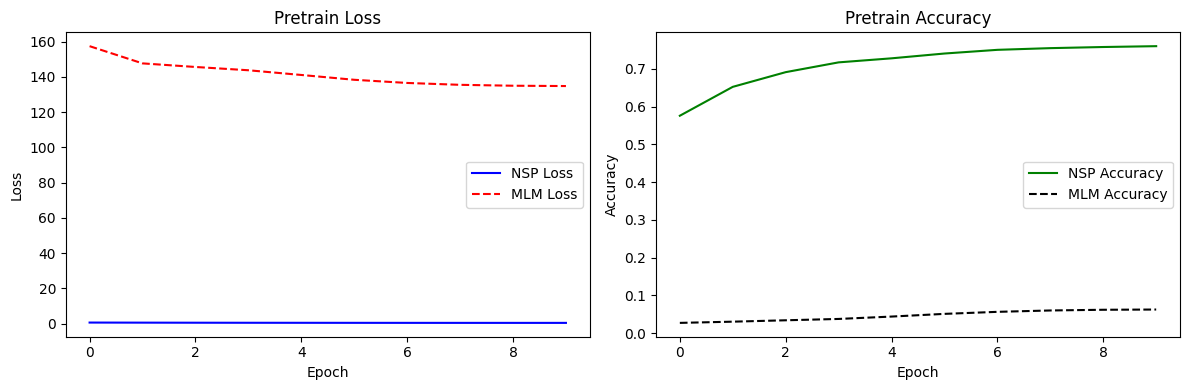

In [31]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['nsp_loss'], 'b-', label='NSP Loss')
plt.plot(history['mlm_loss'], 'r--', label='MLM Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.title('Pretrain Loss')

plt.subplot(1, 2, 2)
plt.plot(history['nsp_acc'], 'g-', label='NSP Accuracy')
plt.plot(history['mlm_acc'], 'k--', label='MLM Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
plt.title('Pretrain Accuracy')

plt.tight_layout()
plt.savefig("/content/models/mini_bert_training_curve.png", dpi=150)
plt.show()

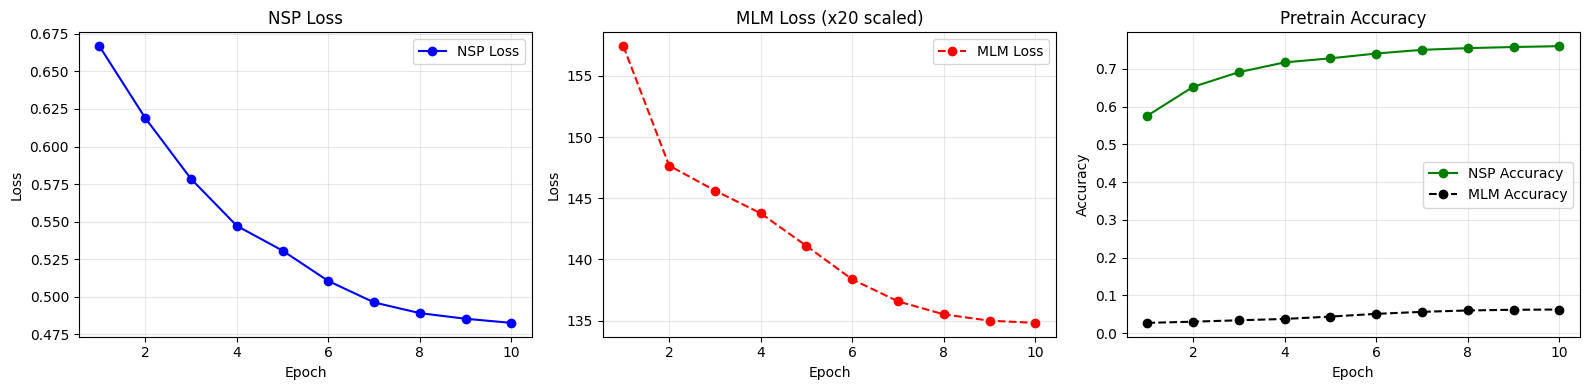

In [32]:
plt.figure(figsize=(16, 4))

# (1) NSP Loss — 별도 subplot으로 분리해서 감소 추세가 보이게
plt.subplot(1, 3, 1)
plt.plot(range(1, len(history['nsp_loss']) + 1), history['nsp_loss'], 'b-', marker='o', label='NSP Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('NSP Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# (2) MLM Loss
plt.subplot(1, 3, 2)
plt.plot(range(1, len(history['mlm_loss']) + 1), history['mlm_loss'], 'r--', marker='o', label='MLM Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('MLM Loss (x20 scaled)')
plt.legend()
plt.grid(True, alpha=0.3)

# (3) Accuracy
plt.subplot(1, 3, 3)
plt.plot(range(1, len(history['nsp_acc']) + 1), history['nsp_acc'], 'g-', marker='o', label='NSP Accuracy')
plt.plot(range(1, len(history['mlm_acc']) + 1), history['mlm_acc'], 'k--', marker='o', label='MLM Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('Pretrain Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/content/models/mini_bert_training_curve.png", dpi=150)
plt.show()

In [33]:
import pandas as pd

df_history = pd.DataFrame({
    'Epoch': range(1, len(history['nsp_loss']) + 1),
    'NSP Loss': [round(v, 4) for v in history['nsp_loss']],
    'MLM Loss': [round(v, 4) for v in history['mlm_loss']],
    'NSP Acc': [round(v, 4) for v in history['nsp_acc']],
    'MLM Acc': [round(v, 4) for v in history['mlm_acc']],
})
df_history

,Epoch,NSP Loss,MLM Loss,NSP Acc,MLM Acc
0,1,0.6667,157.4254,0.5760,0.0269
1,2,0.6190,147.6633,0.6526,0.0301
2,3,0.5785,145.6269,0.6915,0.0338
3,4,0.5473,143.7627,0.7175,0.0373
4,5,0.5307,141.0921,0.7282,0.0436
5,6,0.5105,138.3590,0.7409,0.0508
6,7,0.4963,136.5648,0.7507,0.0561
7,8,0.4891,135.5024,0.7552,0.0598
8,9,0.4854,134.9865,0.7582,0.0616
9,10,0.4827,134.8071,0.7604,0.0623


## 회고
"NSP는 초기에 버그(같은 문서 내에서 랜덤 문장을 뽑던 문제)로 전혀 학습되지 않았으나, 수정 후 accuracy가 0.58→0.76까지 안정적으로 수렴했다. 반면 MLM은 vocab 8000개 중 하나를 맞춰야 하는 어려운 태스크인 데다 모델이 1M 파라미터로 매우 작아 loss가 완만하게만 감소하고 완전히 수렴하지는 않았다. 이는 모델 capacity의 한계로 예상된 결과다."  
다음과 같은 방법으로 성능을 높일 수 있을 것 같다.
1. 데이터를 더 쓰기
작은 모델이라도 같은 20만 건을 10번 반복해서 보는 것보다, 다른 데이터 200만 건을 1~2번 보는 게 일반적으로 훨씬 낫습니다.  
2. MLM loss의 "×20" 재검토
pythonreturn loss * 20   # mlm을 더 잘 학습하도록 20배 증가
이건 튜토리얼에서 온 건데, loss를 20배 하면 gradient도 20배가 되어 사실상 학습률을 MLM 방향으로만 20배 키운 것과 같습니다. 지금 설정(max_lr=2.5e-4 × 20배 gradient)이면 MLM 쪽 실효 학습률이 과도해서 오히려 수렴을 방해하고 있을 가능성이 있어요. ×20을 빼거나 ×2~5 정도로 줄이고, 대신 기본 학습률을 조정하는 실험을 해볼 가치가 있습니다.  
3. 파라미터 "배분" 바꾸기 (총량은 1M 유지)
지금 구조를 보면 임베딩이 8000×64 = 51만 개로 전체 파라미터의 절반 이상을 임베딩이 먹고 있습니다. 정작 문맥을 이해하는 인코더 레이어에는 파라미터가 얼마 안 남은 상태예요. 총 1M을 유지하면서 배분을 바꾸는 방법이 있습니다.
ALBERT가 쓴 임베딩 분해(factorized embedding) 기법인데, 임베딩을 작은 차원(예: 32)으로 만들고 Linear로 d_model에 투영하는 겁니다:
python# 기존: 8000 × 64 = 512,000  
 분해: 8000 × 32 + 32 × 96 = 259,072  → 25만 개 절약
self.embedding = nn.Embedding(n_vocab, 32)
self.embed_proj = nn.Linear(32, d_model)
절약한 파라미터로 d_model을 64→96으로 키우거나 레이어를 4→6으로 늘리면, 같은 1M 예산으로 인코더가 훨씬 커집니다. MLM 성능은 인코더 capacity에 크게 좌우되므로 효과가 있을 가능성이 높습니다.

## 🔧 트러블슈팅: NSP 학습 실패 원인 분석 및 수정

### 1. 문제 발견
최초 10 Epoch 학습 결과, MLM loss는 완만하게 감소했으나 **NSP accuracy가 0.5 근처에 고정**되어 전혀 학습되지 않는 현상을 발견했다. NSP는 이진 분류이므로 accuracy 0.5는 랜덤 추측과 동일한 수준이며, 비교적 쉬운 태스크인 NSP가 전혀 학습되지 않는 것은 모델 크기의 한계가 아닌 다른 원인이 있다고 판단했다.

### 2. 원인 분석
`create_pretrain_instances()` 함수의 NotNext(FALSE) pair 생성 로직을 점검한 결과, 아래와 같은 버그를 발견했다.

```python
# 수정 전 (버그)
random_doc_idx = random.randrange(0, len(doc))   # 뽑아놓고 사용하지 않는 죽은 코드
random_start = random.randrange(0, len(doc))     # doc = "현재 처리 중인 문서"
for j in range(random_start, len(doc)):
    tokens_b.extend(doc[j])
```

NotNext 케이스의 문장 B를 **다른 문서가 아닌, 현재 처리 중인 같은 문서 안에서** 뽑고 있었다. 나무위키 문서는 하나의 주제를 다루므로, 같은 문서에서 뽑은 "가짜 다음 문장"도 실제 다음 문장과 주제가 동일하다. 결과적으로 IsNext와 NotNext 샘플 간 구분 가능한 신호가 거의 없어, 모델이 학습할 수 없는 데이터였던 것이다.

### 3. 수정
전체 문서 리스트(`all_documents`)를 유지하도록 데이터 생성 파이프라인을 재구성하고, NotNext 케이스는 반드시 **현재 문서와 다른 문서**에서 문장을 가져오도록 수정했다.

```python
# 수정 후
random_doc_index = doc_index
while random_doc_index == doc_index and len(all_documents) > 1:
    random_doc_index = random.randrange(0, len(all_documents))  # 다른 문서 보장
```

### 4. 수정 전후 결과 비교

| 지표 | 수정 전 | 수정 후 |
|---|---|---|
| NSP Accuracy | **0.5 고정** (랜덤 수준, 학습 실패) | **0.58 → 0.76** (안정적 수렴) |
| MLM Accuracy | 0.02 → 0.09 | 0.03 → 0.06 (유사) |

수정 후 NSP accuracy가 랜덤 수준(0.5)에서 벗어나 0.76까지 안정적으로 상승하며, NSP 태스크가 정상적으로 학습됨을 확인했다. MLM은 수정 전후 유사한 양상으로, vocab 8000 중 정답을 맞춰야 하는 태스크 난이도 대비 1M 파라미터 모델의 capacity 한계로 loss가 완만하게만 감소하는 것으로 해석된다. 이는 프로젝트 지문에서 언급된 "모델이 작기 때문에 loss가 잘 수렴하지 않을 수 있다"에 부합하는 결과다.|